# 032 小批量随机梯度下降

目标：把无偏条件、方差、完整一次网络更新与预算比较连起来。只用固定合成训练目标，不宣称真实任务泛化或GPU吞吐。先读正文与实验指南。

## 设置与固定输入
从本讲目录启动，重启内核并顺序执行。固定报告与计时快照先校验；之后数值和新计时分开运行。

In [1]:
from pathlib import Path
import hashlib
ROOT=Path.cwd()
EXPECTED={'data/config.json': '3f31d1b740f66a4224b3be2ec56f451d3181e5ccd7a17b6749c5114a2ec51c53', 'data/order.json': 'f90d8e73c6d8c7db11ce5e39f58ff17c6c1fe55d9b9e42d78ce9b011b65553df', 'data/samples.csv': '9b2e5c6d0ac24372075c01f817150430c171d1995363051ac5a861496e67f402', 'outputs/budget-comparison.csv': '472e9fc8df08153e706105811b6d5420a26b69729c9483eb314a612a4141b7ac', 'outputs/first-batch-trace.json': '7895b1484318e25472b914e6ee9384fc42882c591f8e849fd6c2e3628e16c287', 'outputs/measured-timing.json': '59a46c8bc19c1af72d364397e9d8c1b5d4ba219d5456a963c22398e2120a3f34', 'outputs/network-sampling.json': '3351de626b2af616d279c66f02d80b790fb27633ddb267fde2ac63889e819c3e', 'outputs/sampling-exact.json': 'bbb35f893431c17acefdaad8866c561b58f161613ee4f461e6ad70e1778bfd3c', 'outputs/scalar-theory.json': 'c4d44ebfdf31e4293382f3bf10eb70b2248ab10d2f3a7501c41594eed54b2586', 'outputs/summary.json': 'bea11b597a2528abf55a40eb69ce2a8da8f695313c930871a49897b530a89f68', 'outputs/trajectories.json': '47acd15135a2211f8e4de9ef87908c2efe0941f39dcc494f7233d5c3be9d1dcd'}
for name,digest in EXPECTED.items():
    if hashlib.sha256((ROOT/name).read_bytes()).hexdigest()!=digest:
        raise ValueError('固定报告已变动: '+name)
print('3份输入与8份原始输出身份正确')

3份输入与8份原始输出身份正确


In [2]:
import json, tempfile
import numpy as np
import torch
import experiment as e
x,y,orders,cfg=e.load_inputs()
print(torch.__version__,np.__version__,x.shape,y.shape)
print('40个完整排列',all(sorted(row)==list(range(32)) for row in orders))

2.7.1+cpu 2.3.5 (32, 2) (32, 1)
40个完整排列 True


## 精确枚举无偏与协方差
同一固定参数点、同一梯度总体。Fraction字段是精确有理数；不是用有限次模拟近似公式。

In [3]:
sampling=e.sampling_exact()
print('均值',sampling['population_mean'],'协方差',sampling['population_covariance'])
for row in sampling['cases']:
    print(row['batch_size'],row['replacement'],row['possibilities'],row['mean_exact'],row['covariance_exact'])

均值 ['0', '0'] 协方差 [['5', '3/2'], ['3/2', '5/2']]
1 True 4 ['0', '0'] [['5', '3/2'], ['3/2', '5/2']]
1 False 4 ['0', '0'] [['5', '3/2'], ['3/2', '5/2']]
2 True 16 ['0', '0'] [['5/2', '3/4'], ['3/4', '5/4']]
2 False 6 ['0', '0'] [['5/3', '1/2'], ['1/2', '5/6']]
3 True 64 ['0', '0'] [['5/3', '1/2'], ['1/2', '5/6']]
3 False 4 ['0', '0'] [['5/9', '1/6'], ['1/6', '5/18']]
4 True 256 ['0', '0'] [['5/4', '3/8'], ['3/8', '5/8']]
4 False 1 ['0', '0'] [['0', '0'], ['0', '0']]


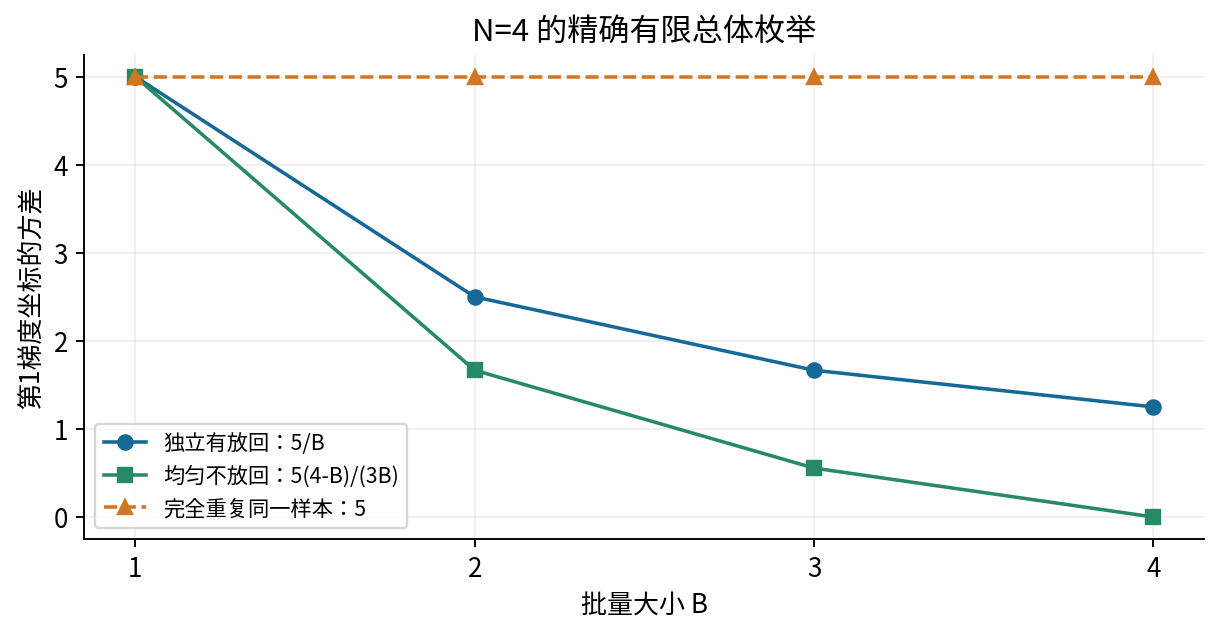

非均匀 {'targets': [-3, -1, 1, 3], 'probabilities': ['1/10', '1/5', '3/10', '2/5'], 'unweighted_expected_gradient': '-1', 'uniform_objective_gradient': '0', 'importance_corrected_values': ['15/2', '5/4', '-5/6', '-15/8'], 'importance_corrected_expectation': '0'}
条件偏差 [{'first_target': -1, 'theta_after_first': '-1/2', 'remaining_target': 1, 'next_gradient': '-3/2', 'full_gradient_here': '-1/2'}, {'first_target': 1, 'theta_after_first': '1/2', 'remaining_target': -1, 'next_gradient': '3/2', 'full_gradient_here': '1/2'}]


In [4]:
from IPython.display import display,Image
display(Image(filename=str(ROOT/'figures/02_variance.png')))
print('非均匀',sampling['nonuniform'])
print('条件偏差',sampling['reshuffle_conditional_counterexample'])

## 标量递推的每个前提
每步独立有放回；噪声与历史独立。下面是精确矩递推，不能当作随机重排网络的定理。

In [5]:
theory=e.scalar_noise_theory()
for row in theory:
    if row['batch_size']==4 and row['learning_rate']==.5 and row['step'] in [0,1,2,10,40]:
        print(row)
print('极限超额损失',5/24)

{'batch_size': 4, 'learning_rate': 0.5, 'step': 0, 'mean_theta': 1.0, 'variance_theta': 0.0, 'expected_excess_loss': 0.5}
{'batch_size': 4, 'learning_rate': 0.5, 'step': 1, 'mean_theta': 0.5, 'variance_theta': 0.3125, 'expected_excess_loss': 0.28125}
{'batch_size': 4, 'learning_rate': 0.5, 'step': 2, 'mean_theta': 0.25, 'variance_theta': 0.390625, 'expected_excess_loss': 0.2265625}
{'batch_size': 4, 'learning_rate': 0.5, 'step': 10, 'mean_theta': 0.0009765625, 'variance_theta': 0.41666626930236816, 'expected_excess_loss': 0.20833361148834229}
{'batch_size': 4, 'learning_rate': 0.5, 'step': 40, 'mean_theta': 9.094947017729282e-13, 'variance_theta': 0.41666666666666663, 'expected_excess_loss': 0.20833333333333331}
极限超额损失 0.20833333333333334


## 同一首批前向全部中间量
ID25、9、6、4。损失含1/2，预测梯度为残差/B，逐量对正文第7节。

In [6]:
trace=e.first_batch_trace(x,y,orders,cfg)
print('ID',trace['ids'],'初始参数',trace['initial'])
for name in ['x','target','affine','hidden','prediction','residual']:
    print(name,trace['shapes'][name],trace['values'][name])
print('loss',trace['loss'])

ID [25, 9, 6, 4] 初始参数 [ 0.3  -0.2  -0.4   0.1   0.2   0.25  0.05 -0.1   0.15  0.4  -0.3   0.2
  0.1 ]
x [4, 2] [[-0.75  0.  ]
 [ 1.   -1.  ]
 [ 0.    0.  ]
 [ 0.75 -0.6 ]]
target [4, 1] [[-0.525]
 [ 0.87 ]
 [-0.03 ]
 [ 0.675]]
affine [4, 3] [[-1.75000000e-01  2.00000000e-01 -2.77555756e-17]
 [ 5.50000000e-01 -6.00000000e-01  1.00000000e-01]
 [ 5.00000000e-02 -1.00000000e-01  1.50000000e-01]
 [ 3.95000000e-01 -4.60000000e-01  1.50000000e-01]]
hidden [4, 3] [[-1.73235158e-01  1.97375320e-01 -2.77555756e-17]
 [ 5.00520211e-01 -5.37049567e-01  9.96679946e-02]
 [ 4.99583750e-02 -9.96679946e-02  1.48885034e-01]
 [ 3.75662661e-01 -4.30084211e-01  1.48885034e-01]]
prediction [4, 1] [[-0.02850666]
 [ 0.48125655]
 [ 0.17966076]
 [ 0.40906733]]
residual [4, 1] [[ 0.49649334]
 [-0.38874345]
 [ 0.20966076]
 [-0.26593267]]
loss 0.06403811492518503


## 同一首批局部链与共享参数累计
先按输出仿射、tanh、输入仿射传回，再把四行对每个共享参数的贡献相加。

In [7]:
for name in ['d_prediction','d_hidden','d_affine','d_input']:
    print(name,trace['shapes'][name],trace['values'][name])
print('13个梯度',trace['gradient'])
print('13个新参数',trace['updated'])
for name in ['affine','hidden','prediction','residual']:
    print('下一次同批',name,trace['next_forward'][name])
print('新loss',trace['next_loss'])

d_prediction [4, 1] [[ 0.12412334]
 [-0.09718586]
 [ 0.05241519]
 [-0.06648317]]
d_hidden [4, 3] [[ 0.04964933 -0.037237    0.02482467]
 [-0.03887434  0.02915576 -0.01943717]
 [ 0.02096608 -0.01572456  0.01048304]
 [-0.02659327  0.01994495 -0.01329663]]
d_affine [4, 3] [[ 0.04815934 -0.03578636  0.02482467]
 [-0.02913553  0.02074659 -0.01924409]
 [ 0.02091375 -0.01556835  0.01025066]
 [-0.02284036  0.01625568 -0.01300189]]
d_input [4, 2] [[ 0.03372728 -0.00700434]
 [-0.02088811  0.00309074]
 [ 0.0145516  -0.00317692]
 [-0.01595476  0.00294317]]
13个梯度 [-0.0823853   0.04283974  0.05977812 -0.0305     -0.04761401  0.02704522
  0.0170972  -0.01435244  0.00282935 -0.09250268  0.10006175 -0.01178083
  0.0128695 ]
13个新参数 [ 0.30164771 -0.20085679 -0.40119556  0.10061     0.20095228  0.2494591
  0.04965806 -0.09971295  0.14994341  0.40185005 -0.30200124  0.20023562
  0.09974261]
下一次同批 affine [[-0.17657772  0.20118372 -0.0007708 ]
 [ 0.55216256 -0.60151851  0.1014366 ]
 [ 0.04965806 -0.09971295 

## 全部坐标的独立梯度检查
独立标量前向参照，不读回被测程序的梯度当答案。

In [8]:
from test_experiment import scalar_reference
theta=np.array(cfg['initial_parameters'],dtype=np.float64)
ids=trace['ids'];fd=[]
for j in range(13):
    plus,minus=theta.copy(),theta.copy()
    plus[j]+=1e-5;minus[j]-=1e-5
    fd.append((scalar_reference(plus,x[ids],y[ids])[0]-scalar_reference(minus,x[ids],y[ids])[0])/2e-5)
print('13坐标差分最大误差',np.max(np.abs(np.array(fd)-trace['gradient'])))

13坐标差分最大误差 3.1422572877026766e-12


## 新运行七份确定性结果
临时目录不覆盖提供的报告。测量时间不在逐字节一致范围里。

In [9]:
temporary=tempfile.TemporaryDirectory()
new=Path(temporary.name)
summary=e.write_report(new)
matching={p.name:p.read_bytes()==(ROOT/'outputs'/p.name).read_bytes() for p in new.iterdir()}
if not all(matching.values()):
    raise RuntimeError('确定性结果不一致')
print(matching)
for row in summary['runs']:
    print(row['budget'],row['batch_size'],row['steps'],row['examples'],row['learning_rate'],row['final_training_loss'])

{'first-batch-trace.json': True, 'network-sampling.json': True, 'scalar-theory.json': True, 'sampling-exact.json': True, 'trajectories.json': True, 'budget-comparison.csv': True, 'summary.json': True}
equal_examples 1 1280 1280 0.02 0.010846523422225036
equal_examples 4 320 1280 0.02 0.04282216935915375
equal_examples 16 80 1280 0.02 0.07010574029094643
equal_examples 32 40 1280 0.02 0.13855836825809162
equal_steps 1 40 40 0.02 0.12674367456211635
equal_steps 4 40 160 0.02 0.1385147314152921
equal_steps 16 40 640 0.02 0.13848299477160145
equal_steps 32 40 1280 0.02 0.13855836825809162
linear_scaled_examples 1 1280 1280 0.005 0.04282831380362236
linear_scaled_examples 4 320 1280 0.02 0.04282216935915375
linear_scaled_examples 16 80 1280 0.08 0.042845428126323415
linear_scaled_examples 32 40 1280 0.16 0.04285187986076876


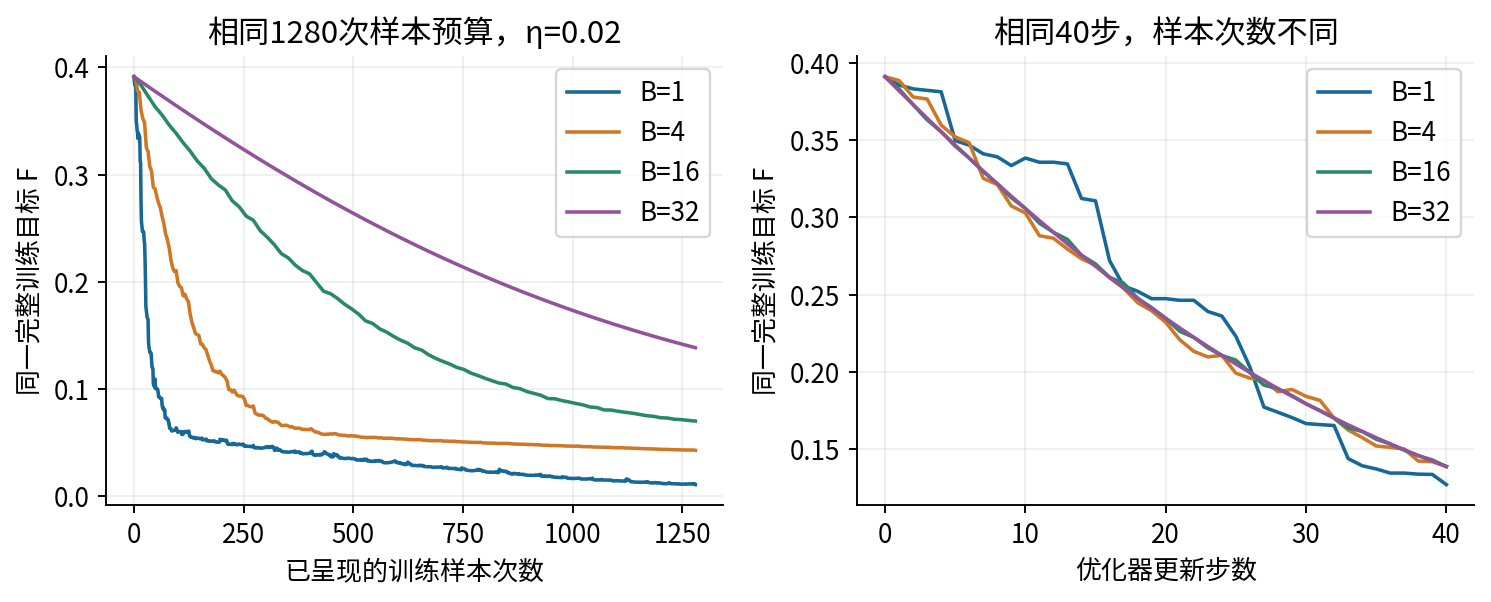

In [10]:
display(Image(filename=str(ROOT/'figures/06_budgets.png')))

## 预提供计时快照与新计时分开
下图来自固定的五次观测。下面另外测当前三次，秒数可以不同；两者都公开实际协议。

{'warmups_each': 1, 'repetitions': 5, 'rotating_order': True, 'timer': 'time.perf_counter_ns', 'included': 'complete train(record=False) call: validation, index flattening, thread setting, tensor initialization, gather/forward/backward/update and guard checks', 'excluded': 'imports, reading/generating original data, full-risk history logging, final comparison audit and file I/O', 'limits': 'Shared CPU wall times vary. Tiny-network implementation timing, not a GPU throughput or general algorithmic superiority claim.'}


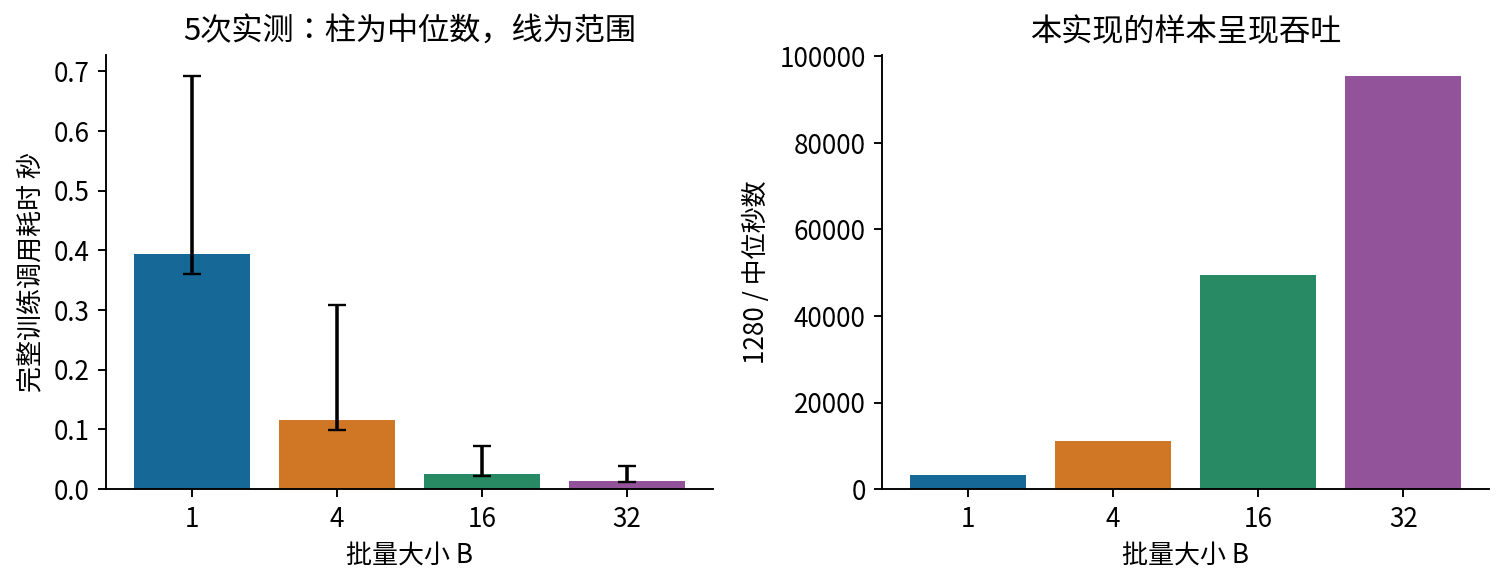

In [11]:
old_timing=json.loads((ROOT/'outputs/measured-timing.json').read_text())
print(old_timing['protocol'])
display(Image(filename=str(ROOT/'figures/08_timings.png')))

In [12]:
import benchmark
new_timing=benchmark.measure(new/'new-timing.json',repetitions=3)
for row in new_timing['rows']:
    print('当前观测',row['batch_size'],row['nanoseconds'],'中位秒',row['median_seconds'])

当前观测 1 [504259975, 408054372, 420631945] 中位秒 0.420631945
当前观测 4 [108297031, 116014883, 110265983] 中位秒 0.110265983
当前观测 16 [29266031, 25101216, 27209780] 中位秒 0.02720978
当前观测 32 [17233896, 18059858, 14011307] 中位秒 0.017233896


## 检查与结论
运行全部独立测试；224个精确协方差场景和所有12条主轨迹不依赖只看最终loss。

In [13]:
import unittest,test_experiment
result=unittest.TextTestRunner(verbosity=1).run(unittest.defaultTestLoader.loadTestsFromModule(test_experiment))
if not result.wasSuccessful():
    raise RuntimeError('测试失败')
temporary.cleanup()

.

.

.

.

.

.

.

.

.

----------------------------------------------------------------------
Ran 9 tests in 2.888s

OK


边界：固定theta的抽样、独立IID标量理论、随机重排小网络是三个不同对象。相同预算必须说清步数/呈现次数/时间。没有GPU、跨平台计时、真实任务泛化或所有批量均条件无偏的结论。浏览器Jupyter与socket通信未实测。来源见sources.md。